## 2. Methode : Regression

- Supervised ML-Methode 
- Ergänzung zum Agent und Company

-------
- Agent: ID of the travel agency that made the booking
	
- Company: ID of the company/entity that made the booking or responsible for paying the booking. ID is presented instead of 

- adr :Average Daily Rate Calculated by dividing the sum of all lodging transactions by the total number of staying 
--------


adr ist für die Target variable

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')



### Daten Einlesen und Feature Engineering

Wir lesen die Daten ein kontrollieren die Qualität und führen ein Feature Engineering durch.

In [2]:
df = pd.read_csv("/Users/I585032/Desktop/AI Data Analyst M1/hotel_bookings_processed.csv", 
                 sep=";")  # ← DAS FEHLTE!



# Bereits identifizierte nicht benötigte Spalten entfernen
notinuse_col = ['reservation_status_date',
               'arrival_date_year',
               #'arrival_date_month',
               'arrival_date_week_number', 
               'assigned_room_type',
               'reservation_status',
                'arrival_date']
df = df.drop(columns=notinuse_col)

# Null-Werte verarbeiten
print(f"Anzahl der Null-Werte vor der Bereinigung: {df.isnull().sum().sum()}")

Anzahl der Null-Werte vor der Bereinigung: 0


In [3]:
# Calculate the percentage of bookings for each country
country_percentages = (df['country'].value_counts() / len(df)) * 100

# Identify countries with less than 1% of bookings
countries_below_1_percent = country_percentages[country_percentages < 1].index.tolist()

# Replace countries below 1% with 'Sonstiges'
df['country'] = df['country'].apply(lambda x: 'Sonstiges' if x in countries_below_1_percent else x)

print(f"Anzahl der Länder nach Gruppierung: {df['country'].nunique()}")
print("\nVerteilung nach Gruppierung:")
print(df['country'].value_counts())

# Fehlende numerische Werte mit Median ersetzen
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fehlende kategorische Werte mit Modus ersetzen
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Anzahl der Null-Werte nach der Bereinigung: {df.isnull().sum().sum()}")



Anzahl der Länder nach Gruppierung: 15

Verteilung nach Gruppierung:
country
PRT          49078
GBR          12129
Sonstiges    11733
FRA          10415
ESP           8568
DEU           7287
ITA           3766
IRL           3375
BEL           2342
BRA           2224
NLD           2104
USA           2097
CHE           1730
CN            1279
AUT           1263
Name: count, dtype: int64
Anzahl der Null-Werte nach der Bereinigung: 0


In [4]:

# 2. Feature Engineering - neue Features erstellen
print("Feature Engineering...")

# Gesamtaufenthaltsdauer
df['total_stay_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

# Gesamtanzahl der Gäste
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies'].fillna(0)

# Flexibilitätsindex (Vorlaufzeit / Aufenthaltsdauer)
df['flexibility_index'] = df['lead_time'] / (df['total_stay_nights'] + 1)

# Vorverarbeitung der Ankunftsdaten für weitere Analysen
month_map = {'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
             'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12}

# 3. Daten für die Regression vorbereiten
# Target Variable definieren
y = df['adr']

# Entferne die Target Variable aus den Features
X = df.drop('adr', axis=1)

# Kategorische Variablen identifizieren
cat_features = X.select_dtypes(include=['object']).columns.tolist()
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Trainings- und Testdaten aufteilen
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Feature Engineering...


In [5]:
# Vollständige Übersicht aller Variablen mit Eigenschaften und Datentypen
print(f"Anzahl der Spalten: {len(df.columns)}")
print(f"Anzahl der Zeilen: {len(df)}")
print("\n" + "="*80)
print("VOLLSTÄNDIGE VARIABLENÜBERSICHT")
print("="*80 + "\n")

# Detaillierte Informationen zu allen Spalten
variable_info = pd.DataFrame({
    'Variable': df.columns,
    'Datentyp': df.dtypes.values,
    'Nicht-Null': df.notna().sum().values,
    'Fehlend': df.isna().sum().values,
    'Unique': [df[col].nunique() for col in df.columns],
    'Min': [df[col].min() if df[col].dtype in ['int64', 'float64'] else '-' for col in df.columns],
    'Max': [df[col].max() if df[col].dtype in ['int64', 'float64'] else '-' for col in df.columns]
})

# Ausgabe der vollständigen Liste
print(variable_info.to_string(index=False))

# Zusätzliche Statistik nach Datentyp
print("\n" + "="*80)
print("ZUSAMMENFASSUNG NACH DATENTYP")
print("="*80)
print(df.dtypes.value_counts())

Anzahl der Spalten: 31
Anzahl der Zeilen: 119390

VOLLSTÄNDIGE VARIABLENÜBERSICHT

                      Variable Datentyp  Nicht-Null  Fehlend  Unique   Min      Max
                         hotel   object      119390        0       2     -        -
                   is_canceled    int64      119390        0       2     0        1
                     lead_time    int64      119390        0     479     0      737
     arrival_date_day_of_month    int64      119390        0      31     1       31
       stays_in_weekend_nights    int64      119390        0      17     0       19
          stays_in_week_nights    int64      119390        0      35     0       50
                        adults    int64      119390        0      14     0       55
                      children  float64      119390        0       5   0.0     10.0
                        babies    int64      119390        0       5     0       10
                          meal   object      119390        0       5     -   

In [6]:
# 4. Feature Selektion durch Korrelationsanalyse
print("Feature-Selektion wird durchgeführt...")

# One-Hot-Encoding für kategorische Variablen mit handle_unknown='ignore'
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_features)
    ])

# Trainings und Test-Daten transformieren
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Spaltenbezeichnungen erzeugen
num_feature_names = num_features
cat_feature_names = []
for i, col in enumerate(cat_features):
    # OneHotEncoder erzeugt für jede Kategorie eine Dummy-Variable, außer für die erste (drop='first')
    categories = preprocessor.named_transformers_['cat'].categories_[i][1:]  # Erste Kategorie überspringen
    cat_feature_names.extend([f"{col}_{cat}" for cat in categories])

all_feature_names = num_feature_names + cat_feature_names

# Daten als DataFrame mit passenden Spaltennamen
X_train_transformed = pd.DataFrame(X_train_transformed, 
                                  columns=all_feature_names, 
                                  index=X_train.index)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Konstantenspalte für Intercept hinzufügen
X_train_sm = sm.add_constant(X_train_transformed)
X_test_sm = sm.add_constant(X_test_transformed)

# 5. Schrittweise Feature-Selektion mit p-Werten
def stepwise_selection(X, y, initial_list=[], threshold_in=0.01, threshold_out=0.05, verbose=False, max_features=None):
    included = list(initial_list)
    
    while True:
        changed = False
        
        # Forward step
        excluded = list(set(X.columns) - set(included))
        new_pval = pd.Series(index=excluded, dtype='float64')
        for new_column in excluded:
            model = sm.OLS(y, sm.add_constant(X[included + [new_column]])).fit()
            new_pval[new_column] = model.pvalues[new_column]
        
        if not new_pval.empty:
            best_pval = new_pval.min()
            
            if best_pval < threshold_in:
                best_feature = new_pval.idxmin()
                included.append(best_feature)
                changed = True
                if verbose:
                    print(f'Add  {best_feature} with p-value {best_pval:.6f}')
                
                # Optional: Begrenze die maximale Anzahl an Features
                if max_features and len(included) >= max_features:
                    break
        
        # Backward step (nur wenn Features vorhanden sind)
        if included:
            model = sm.OLS(y, sm.add_constant(X[included])).fit()
            # Verwende alle p-Werte außer für Konstante
            pvalues = model.pvalues.iloc[1:] if hasattr(model.pvalues, 'iloc') else pd.Series(model.pvalues)[1:]
            
            if not pvalues.empty:
                worst_pval = pvalues.max()
                
                if worst_pval > threshold_out:
                    worst_feature = pvalues.idxmax()
                    included.remove(worst_feature)
                    changed = True
                    if verbose:
                        print(f'Drop {worst_feature} with p-value {worst_pval:.6f}')
        
        if not changed:
            break
            
    return included

print("Schrittweise Variablenselektion wird durchgeführt...")
# Begrenze auf max. 20 Features für bessere Interpretierbarkeit
selected_features = stepwise_selection(X_train_transformed, y_train, verbose=True, max_features=20)
print(f"Ausgewählte Features: {selected_features}")
print(f"Anzahl ausgewählter Features: {len(selected_features)}")

# Rest des Codes bleibt unverändert...

Feature-Selektion wird durchgeführt...
Schrittweise Variablenselektion wird durchgeführt...
Add  company with p-value 0.000000
Add  market_segment_Offline TA/TO with p-value 0.000000
Add  market_segment_Online TA with p-value 0.000000
Add  reserved_room_type_F with p-value 0.000000
Add  children with p-value 0.000000
Add  market_segment_Complementary with p-value 0.000000
Add  distribution_channel_Direct with p-value 0.000000
Add  hotel_Resort Hotel with p-value 0.000000
Add  reserved_room_type_E with p-value 0.000000
Add  reserved_room_type_D with p-value 0.000000
Add  total_guests with p-value 0.000000
Add  meal_HB with p-value 0.000000
Drop company with p-value 0.477444
Add  reserved_room_type_G with p-value 0.000000
Add  reserved_room_type_H with p-value 0.000000
Add  reserved_room_type_C with p-value 0.000000
Add  meal_SC with p-value 0.000000
Add  market_segment_Direct with p-value 0.000000
Drop distribution_channel_Direct with p-value 0.052763
Add  meal_FB with p-value 0.000000



Modell-Zusammenfassung:
                            OLS Regression Results                            
Dep. Variable:                    adr   R-squared:                       0.363
Model:                            OLS   Adj. R-squared:                  0.363
Method:                 Least Squares   F-statistic:                     2726.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:03:54   Log-Likelihood:            -4.8985e+05
No. Observations:               95512   AIC:                         9.797e+05
Df Residuals:                   95491   BIC:                         9.799e+05
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

Text(0.5, 1.0, 'Tatsächliche vs. Vorhergesagte ADR')

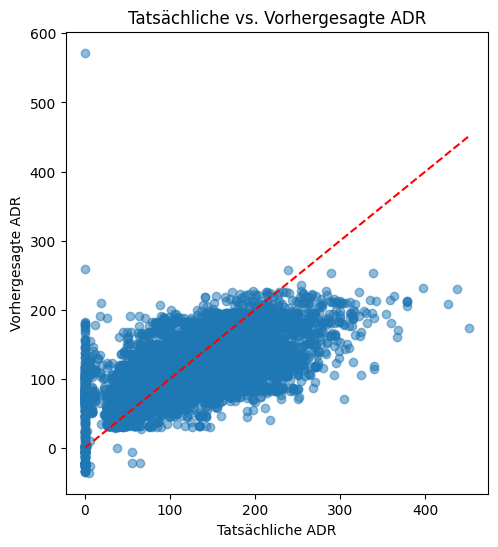

In [7]:

# 6. Finales Modell bauen und evaluieren
X_train_selected = X_train_transformed[selected_features]
X_test_selected = X_test_transformed[selected_features]

# Konstante hinzufügen
X_train_selected = sm.add_constant(X_train_selected)
X_test_selected = sm.add_constant(X_test_selected)

# Modell mit ausgewählten Features trainieren
final_model = sm.OLS(y_train, X_train_selected).fit()

# Modellzusammenfassung anzeigen
print("\nModell-Zusammenfassung:")
print(final_model.summary())

# Vorhersagen treffen
y_pred = final_model.predict(X_test_selected)

# Modell bewerten
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("\nModell-Performance auf Testdaten:")
print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

# 7. Visualisierungen
plt.figure(figsize=(12, 6))

# Tatsächliche vs. vorhergesagte Werte
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Tatsächliche ADR')
plt.ylabel('Vorhergesagte ADR')
plt.title('Tatsächliche vs. Vorhergesagte ADR')



y_pred shape: (23878,)
y_test shape: (23878,)
residuals shape: (42909,)


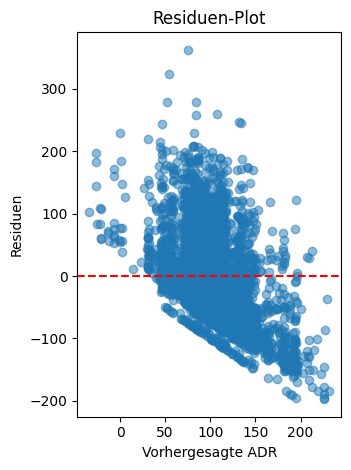

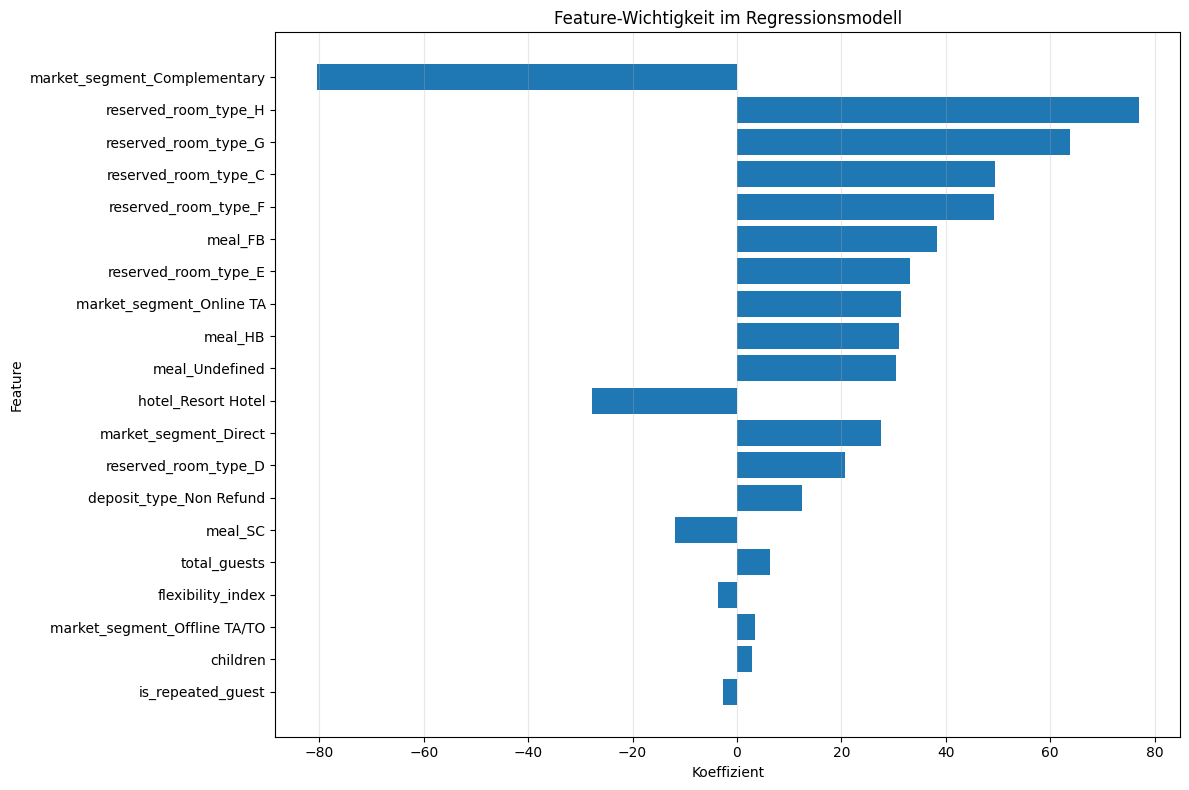

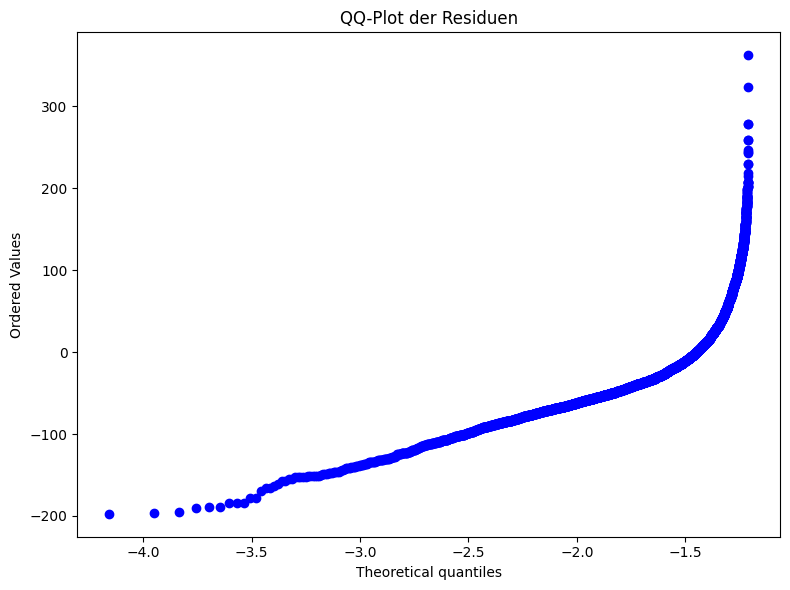

In [8]:
# Residuen-Plot
residuals = y_test - y_pred

# Check shapes before plotting
print(f"y_pred shape: {y_pred.shape if hasattr(y_pred, 'shape') else len(y_pred)}")
print(f"y_test shape: {y_test.shape if hasattr(y_test, 'shape') else len(y_test)}")
print(f"residuals shape: {residuals.shape if hasattr(residuals, 'shape') else len(residuals)}")

# Make sure both arrays have the same index and length
if isinstance(y_pred, pd.Series) and isinstance(residuals, pd.Series):
    # Align indices
    y_pred, residuals = y_pred.align(residuals)
else:
    # Convert to numpy arrays if needed
    y_pred = np.array(y_pred)
    residuals = np.array(residuals)

# Now plot with properly aligned data
plt.subplot(1, 2, 2)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Vorhergesagte ADR')
plt.ylabel('Residuen')
plt.title('Residuen-Plot')

plt.tight_layout()
plt.show()

# Feature-Wichtigkeit aus Koeffizienten visualisieren (nur für ausgewählte Features)
coef_df = pd.DataFrame({
    'Feature': final_model.params.index[1:],  # Konstante überspringen
    'Koeffizient': final_model.params.values[1:]
})

plt.figure(figsize=(12, 8))
coef_df = coef_df.reindex(coef_df['Koeffizient'].abs().sort_values().index)
plt.barh(coef_df['Feature'], coef_df['Koeffizient'])
plt.xlabel('Koeffizient')
plt.ylabel('Feature')
plt.title('Feature-Wichtigkeit im Regressionsmodell')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Zusätzlicher diagnostischer Plot: QQ-Plot für die Residuen
from scipy import stats
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title('QQ-Plot der Residuen')
plt.tight_layout()
plt.show()